# CNN - Оценка на модела (Evaluation)
Този ноутбук зарежда обучения модел и го оценява върху тестовия набор от данни.

In [2]:
import os
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.models.LSTM import AudioLSTM
from src.data_processing.audio_dataset import AudioFolderDataset

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Използвано устройство: {DEVICE}")

TEST_CSV = "../data/test_split.csv"
AUDIO_DIR = "../data/Dataset_Final"
MODEL_WEIGHTS = "../models/best_lstm.pth"
BATCH_SIZE = 32

Използвано устройство: cpu


In [4]:
print("Зареждане на тестовите данни...")
# Използвай новия параметър csv_file
test_dataset = AudioFolderDataset(root_dir="../data/Dataset_Final", csv_file=TEST_CSV, augment=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Брой тестови записи: {len(test_dataset)}")


Зареждане на тестовите данни...
Зареждане на данни от сплит файл: ../data/test_split.csv
Брой тестови записи: 443


In [6]:
print("Инициализация на модела...")
model = AudioLSTM().to(DEVICE)

print("Зареждане на запазените тегла...")
if os.path.exists(MODEL_WEIGHTS):
    model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=DEVICE))
    model.eval()
    print("Моделът е зареден успешно!")
else:
    print(f"ГРЕШКА: Файлът с теглата не е намерен на път {MODEL_WEIGHTS}")

Инициализация на модела...
Зареждане на запазените тегла...
Моделът е зареден успешно!


In [7]:
all_preds = []
all_labels = []

print("Стартиране на инференцията...")
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Оценката приключи!")

test_acc = accuracy_score(all_labels, all_preds)
print(f"Тестова точност (Test Accuracy): {test_acc:.4f} ({test_acc*100:.2f}%)")

Стартиране на инференцията...


Testing:   0%|          | 0/14 [00:00<?, ?it/s]

Оценката приключи!
Тестова точност (Test Accuracy): 0.4673 (46.73%)


In [8]:
class_names = [
    "Baby_Cry", "Background", "Car_Horn", "Construction", 
    "Dog_Bark", "Door_Signal", "Glass_Break", "Siren_Alarm"
]


print("--- Доклад от класификацията (Classification Report) ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

--- Доклад от класификацията (Classification Report) ---
              precision    recall  f1-score   support

    Baby_Cry       0.45      0.23      0.30        40
  Background       0.63      0.41      0.50        70
    Car_Horn       0.36      0.35      0.35        43
Construction       0.70      0.47      0.56        70
    Dog_Bark       0.37      0.66      0.47        70
 Door_Signal       0.40      0.05      0.09        40
 Glass_Break       0.33      0.40      0.36        40
 Siren_Alarm       0.52      0.81      0.63        70

    accuracy                           0.47       443
   macro avg       0.47      0.42      0.41       443
weighted avg       0.49      0.47      0.44       443



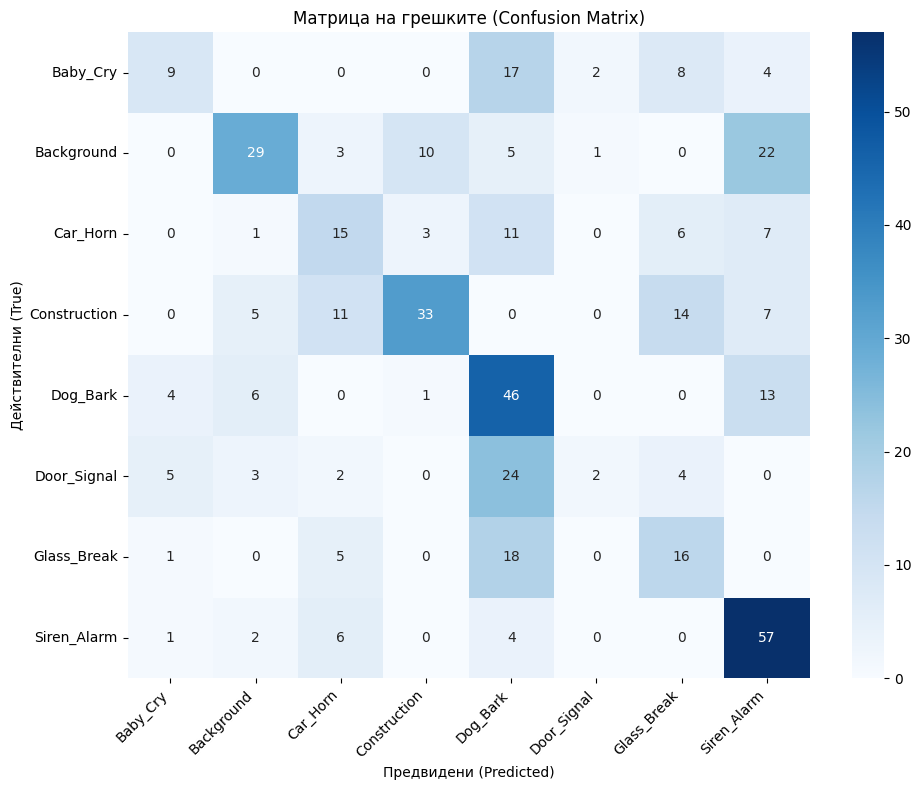

In [9]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Предвидени (Predicted)')
plt.ylabel('Действителни (True)')
plt.title('Матрица на грешките (Confusion Matrix)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Анализ на резултатите: AudioLSTM Sound Classification
1. Общ преглед на производителността
Моделът AudioLSTM показва незадоволителни резултати с обща точност (Accuracy) от едва 47%. За разлика от CNN архитектурите, които разглеждат спектрограмата като изображение, LSTM се опитва да я анализира като времеви ред, което в случая води до значителни затруднения.

Ключови метрики:

Precision (Macro Avg): 0.47

Recall (Macro Avg): 0.42

F1-Score (Weighted Avg): 0.44

2. Детайлен анализ по класове
✅ Относително стабилни класове

🚨 Siren_Alarm: Това е единственият клас с прилично представяне — 0.81 Recall. LSTM успява да улови периодичния характер на сирената по-добре от другите звуци.

🐕 Dog_Bark: Постига 0.66 Recall, но с много ниска прецизност (0.37). Подобно на базовия CNN, тук LSTM бърка почти всичко останало за кучешки лай.

❌ Провал при специфични сигнали

🔔 Door_Signal (0.05 Recall): Моделът е практически „сляп“ за този клас. Само 2 от 40 записа са разпознати правилно. 24 от случаите са грешно класифицирани като кучешки лай.

👶 Baby_Cry (0.23 Recall): Много лошо представяне. LSTM не успява да разграничи фините модулации на бебешкия глас, бъркайки го основно с Dog_Bark (17 случая) и Glass_Break (8 случая).

🚗 Car_Horn: Само 15 от 43 клаксона са уловени, което е критичен пропуск за безопасността на пътя.

3. Анализ на объркването (Confusion)
Матрицата на грешките разкрива хаотично разпределение:

Glass_Break се разсейва почти по равно между Dog_Bark, Construction и собствения си клас.

Background (фоновият шум) често се бърка със сирени (22 случая), което би довело до постоянен поток от фалшиви аларми в реално приложение.